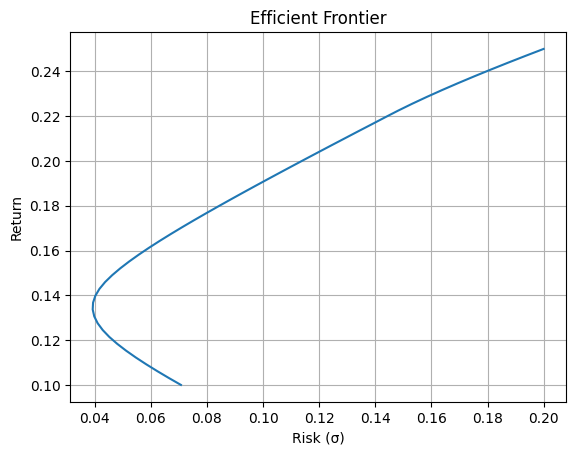


Q1(B): 10 Portfolios on Efficient Frontier
Weights			Return	Risk
[1. 0. 0.] 0.1 0.071
[0.889 0.111 0.   ] 0.117 0.05
[0.778 0.222 0.   ] 0.133 0.039
[0.66 0.33 0.01] 0.15 0.047
[0.504 0.419 0.077] 0.167 0.066
[0.349 0.508 0.143] 0.183 0.089
[0.194 0.597 0.209] 0.2 0.114
[0.052 0.693 0.255] 0.217 0.139
[0.    0.833 0.167] 0.233 0.167
[0. 1. 0.] 0.25 0.2

Q1(C): Risk = 15%
Minimum Return: 0.2224489796045916 Weights: [0.    0.724 0.276]
Maximum Return: 0.2255102040821024 Weights: [0.    0.755 0.245]

Q1(D): Return = 18%
Weights: [0.38 0.49 0.13]
Risk: 0.084

Q1(E): Market Portfolio
Weights: [0.704 0.296 0.   ]
Return: 0.144
Risk: 0.043


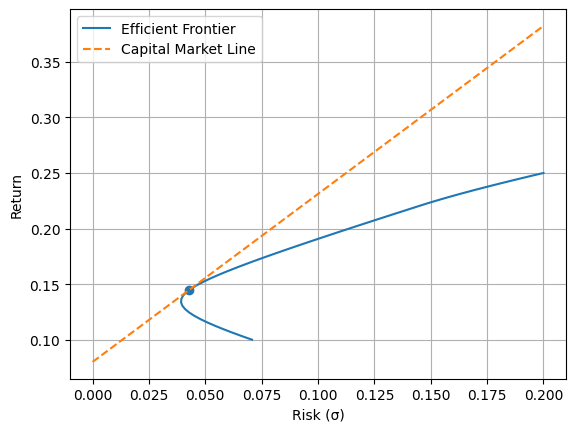


Q1(F): Risky + Risk-Free Combinations
Target Risk 10% → Risky: 2.348, Risk-Free: -1.348
Target Risk 25% → Risky: 5.871, Risk-Free: -4.871


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

mu = np.array([0.10, 0.25, 0.15])

C = np.array([
    [0.005, -0.010,  0.004],
    [-0.010, 0.040, -0.002],
    [0.004, -0.002, 0.023]
])

rf = 0.08
n = len(mu)

def port_return(w):
    return np.dot(w, mu)

def port_risk(w):
    return np.sqrt(np.dot(w.T, np.dot(C, w)))

def min_variance(target_return):
    def objective(w):
        return np.dot(w.T, np.dot(C, w))

    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: port_return(w) - target_return}
    )

    bounds = [(0, 1)] * n
    w0 = np.ones(n) / n

    result = minimize(objective, w0, bounds=bounds, constraints=constraints)
    return result.x

target_returns = np.linspace(mu.min(), mu.max(), 50)

ef_risk = []
ef_return = []
ef_weights = []

for r in target_returns:
    w = min_variance(r)
    ef_weights.append(w)
    ef_risk.append(port_risk(w))
    ef_return.append(port_return(w))

# Plot Efficient Frontier
plt.figure()
plt.plot(ef_risk, ef_return)
plt.xlabel("Risk (σ)")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.grid()
plt.show()

print("\nQ1(B): 10 Portfolios on Efficient Frontier")
print("Weights\t\t\tReturn\tRisk")

for r in np.linspace(mu.min(), mu.max(), 10):
    w = min_variance(r)
    print(np.round(w, 3), round(port_return(w), 3), round(port_risk(w), 3))

target_risk = 0.15
closest = []

for w in ef_weights:
    if abs(port_risk(w) - target_risk) < 0.005:
        closest.append((port_return(w), w))

min_ret, w_min = min(closest, key=lambda x: x[0])
max_ret, w_max = max(closest, key=lambda x: x[0])

print("\nQ1(C): Risk = 15%")
print("Minimum Return:", min_ret, "Weights:", np.round(w_min, 3))
print("Maximum Return:", max_ret, "Weights:", np.round(w_max, 3))


target_return = 0.18
w = min_variance(target_return)

print("\nQ1(D): Return = 18%")
print("Weights:", np.round(w, 3))
print("Risk:", round(port_risk(w), 3))

def neg_sharpe(w):
    return -(port_return(w) - rf) / port_risk(w)

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = [(0, 1)] * n
w0 = np.ones(n) / n

res = minimize(neg_sharpe, w0, bounds=bounds, constraints=constraints)

w_m = res.x
r_m = port_return(w_m)
sigma_m = port_risk(w_m)

print("\nQ1(E): Market Portfolio")
print("Weights:", np.round(w_m, 3))
print("Return:", round(r_m, 3))
print("Risk:", round(sigma_m, 3))

# Capital Market Line
cml_x = np.linspace(0, max(ef_risk), 50)
cml_y = rf + (r_m - rf) / sigma_m * cml_x

plt.figure()
plt.plot(ef_risk, ef_return, label="Efficient Frontier")
plt.plot(cml_x, cml_y, '--', label="Capital Market Line")
plt.scatter(sigma_m, r_m)
plt.xlabel("Risk (σ)")
plt.ylabel("Return")
plt.legend()
plt.grid()
plt.show()


print("\nQ1(F): Risky + Risk-Free Combinations")

for target_sigma in [0.10, 0.25]:
    w_risky = target_sigma / sigma_m
    w_rf = 1 - w_risky
    print(f"Target Risk {target_sigma*100:.0f}% → Risky: {round(w_risky,3)}, Risk-Free: {round(w_rf,3)}")


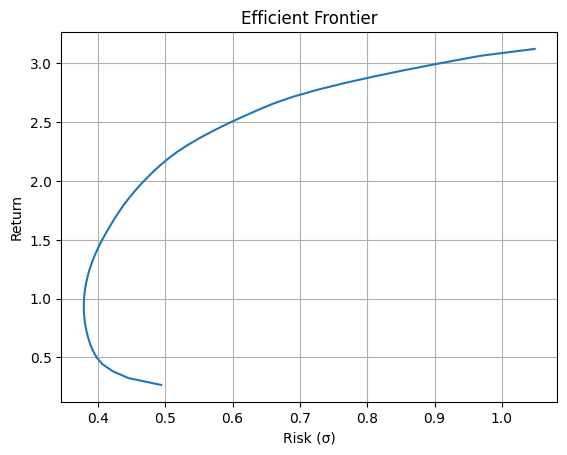

Market portfolio weights:
 [0.00000000e+00 3.15197792e-16 4.81125302e-01 0.00000000e+00
 0.00000000e+00 1.40814901e-02 0.00000000e+00 1.63394593e-01
 3.41398615e-01 0.00000000e+00]
Market return: 2.2213679608275205
Market risk: 0.5113713702907217


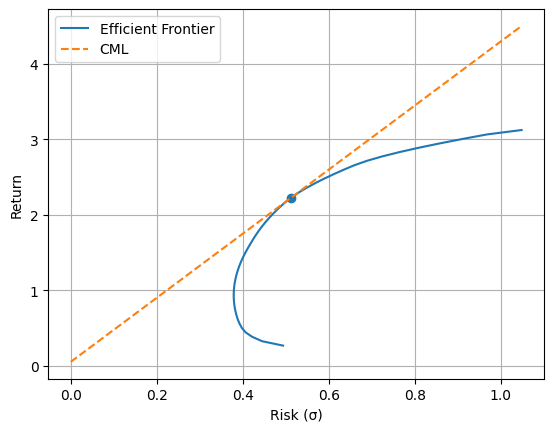

C:\Users\rehan\AppData\Local\Temp\ipykernel_13012\1377871987.py:129: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(beta[i], mu[i], stock)


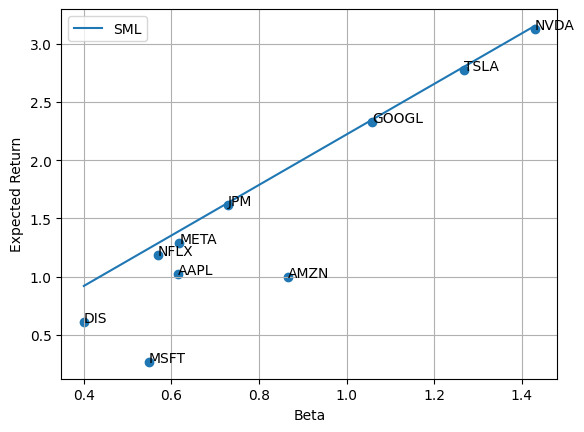

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

df = pd.read_csv("stocks.csv")
prices = df.iloc[:, 1:]

returns = prices.pct_change().dropna()

mu = returns.mean() * 252          # annual mean returns
cov = returns.cov() * 252          # annual covariance
n = len(mu)

rf = 0.05                          # risk-free rate

def port_return(w):
    return np.dot(w, mu)

def port_risk(w):
    return np.sqrt(np.dot(w.T, np.dot(cov, w)))

def min_variance(target_return):
    def obj(w):
        return np.dot(w.T, np.dot(cov, w))

    cons = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: port_return(w) - target_return}
    )

    bounds = [(0, 1)] * n
    w0 = np.ones(n) / n

    res = minimize(obj, w0, bounds=bounds, constraints=cons)
    return res.x

target_returns = np.linspace(mu.min(), mu.max(), 50)

ef_risk = []
ef_return = []

for r in target_returns:
    w = min_variance(r)
    ef_risk.append(port_risk(w))
    ef_return.append(port_return(w))

plt.figure()
plt.plot(ef_risk, ef_return)
plt.xlabel("Risk (σ)")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.grid()
plt.show()

def neg_sharpe(w):
    return -(port_return(w) - rf) / port_risk(w)

cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = [(0, 1)] * n
w0 = np.ones(n) / n

res = minimize(neg_sharpe, w0, bounds=bounds, constraints=cons)

w_m = res.x
r_m = port_return(w_m)
sigma_m = port_risk(w_m)

print("Market portfolio weights:\n", w_m)
print("Market return:", r_m)
print("Market risk:", sigma_m)


cml_x = np.linspace(0, max(ef_risk), 50)
cml_y = rf + (r_m - rf) / sigma_m * cml_x

plt.figure()
plt.plot(ef_risk, ef_return, label="Efficient Frontier")
plt.plot(cml_x, cml_y, '--', label="CML")
plt.scatter(sigma_m, r_m)
plt.xlabel("Risk (σ)")
plt.ylabel("Return")
plt.legend()
plt.grid()
plt.show()

market_returns = returns @ w_m
beta = []

for stock in returns.columns:
    cov_im = np.cov(returns[stock], market_returns)[0, 1]
    beta.append(cov_im / np.var(market_returns))

beta = np.array(beta)

expected_returns = rf + beta * (r_m - rf)

beta_line = np.linspace(beta.min(), beta.max(), 50)
sml_line = rf + beta_line * (r_m - rf)

plt.figure()
plt.plot(beta_line, sml_line, label="SML")
plt.scatter(beta, mu)

for i, stock in enumerate(prices.columns):
    plt.text(beta[i], mu[i], stock)

plt.xlabel("Beta")
plt.ylabel("Expected Return")
plt.legend()
plt.grid()
plt.show()
